# 2D Mesh Cell-Size Sensitivity for Sediment Transport

**Model:** Chippewa River 2D (`Chippewa_2D`, HEC's *2D Sediment Transport* example suite, plan *"100ft Sediment"*)

This notebook studies how **2D mesh cell size affects mobile-bed sediment-transport results** in
HEC-RAS. It clones a clean 2D sediment model, regenerates its mesh across a wide range of cell
sizes (**10 ft up to twice the base spacing**), runs each over an identical flow window, and
compares the resulting **bed change, transport, and bed-gradation** fields.

Stanford Gibson (HEC's sediment lead) has repeatedly noted that **2D mesh resolution is not a
neutral numerical choice for sediment**: bed-material transport scales steeply with local velocity
and shear (often ~V^3-V^4), and those peaks are exactly what a coarse mesh averages away. Refining
the mesh therefore changes not just the hydraulics but the *predicted erosion and deposition
pattern* itself. This notebook makes that sensitivity visible.

## Important: Limitations of Headless Mesh Regeneration

This example deliberately uses a **structure-free, breakline-free 2D area** so that cell size is the
*only* variable. That choice is intentional, and the reason is a real limitation of regenerating a
mesh underneath an existing model:

> **Changing cell size can invalidate structures whose connections sit on a spacing-controlled
> breakline.** Gated spillways, culverts, weirs, and SA/2D connections attach to specific 2D cells.
> When the mesh is regenerated at a different resolution, the cell adjacent to that connection takes
> on a *different terrain-averaged elevation*. If that cell elevation rises above the structure's
> control elevation, HEC-RAS rejects the connection at compute time, e.g.:
>
> ```
> ERROR with Connection(s)
> gate Gate #1   gate elev   593.00
> cell    17615  cell elev   598.96     <- finer-mesh cell now higher than the gate
> ```
>
> This is exactly what happens if you try a naive cell-size sweep on a model like
> *BaldEagleCrkMulti2D* (Sayers Dam). Every mesh finer than the original fails - not because the
> hydraulics are wrong, but because the **model became invalid** at the new resolution.

**These failures *can* be addressed** - by lowering the structure control elevation below the
finest-mesh cell elevation, pinning the breakline `near`/`far` spacing so the connection cell is
stable across resolutions, or protecting the connection cells - but it is **model-specific and
fiddly**, and it confounds a clean cell-size study. So for a *sediment* mesh-sensitivity
demonstration we use the Chippewa River 2D area, which has **no internal structures and no
breaklines**. We still inspect for breaklines below and explain what we *would* analyze if any
existed.

The cost of resolution is also steep: cell count grows ~ (1 / cell_size)^2, and a mobile-bed
sediment run does meaningful work per cell per step. The runtime table later in this notebook shows
why the very finest meshes are gated behind a configurable cell budget rather than run by default.

## What You'll Learn

- Regenerate a 2D mesh across cell sizes with `GeomMesh.generate(cell_size=...)`
- Inspect and (when present) analyze **breakline spacing** with the `GeomMesh` breakline API
- Hold the flow window constant across meshes so a sediment comparison is apples-to-apples
- Read **2D mobile-bed results** - `Cell Bed Change`, `Cell Bed Elevation`, active-layer `D50` -
  from the plan HDF
- Quantify resolution sensitivity: net/erosion/deposition **bed-change volume**, peak scour and
  deposition, and active-layer **coarsening (D50)**
- Visualize how the spatial **bed-change pattern** sharpens as the mesh refines

## Prerequisites
- Windows + HEC-RAS 6.x (mobile-bed 2D sediment)
- `ras-commander` (local source toggle below)
- Runtime: the default executed sweep (400 -> 50 ft) finishes in a few minutes; finer meshes are
  gated (see runtime table).

## Setup

In [1]:
# =============================================================================
# DEVELOPMENT MODE TOGGLE
# =============================================================================
USE_LOCAL_SOURCE = True  # <-- load ras_commander from this repo, not the installed package

import sys
from pathlib import Path
if USE_LOCAL_SOURCE:
    local_path = str(Path.cwd().parent)
    if local_path not in sys.path:
        sys.path.insert(0, local_path)
    print(f"LOCAL SOURCE MODE: {local_path}/ras_commander")

import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py

from ras_commander import init_ras_project, RasExamples, RasPlan, RasCmdr
from ras_commander.geom.GeomMesh import GeomMesh
from ras_commander.hdf import HdfResultsPlan, HdfResultsSediment

import ras_commander
print(f"Loaded: {ras_commander.__file__}")

LOCAL SOURCE MODE: G:\GH\ras-commander/ras_commander


Loaded: G:\GH\ras-commander\ras_commander\__init__.py


## Parameters

In [2]:
# =============================================================================
# PARAMETERS
# =============================================================================
PROJECT_NAME  = "Chippewa_2D"
RAS_VERSION   = "7.0"
TEMPLATE_PLAN = "02"            # "100ft Sediment" plan (mobile bed)
MESH_NAME     = "Perimeter 1"   # the single 2D flow area
SUFFIX        = "230_sed_meshsens"

# Base nominal spacing of the shipped mesh is ~200 ft (the as-built mesh is 433 cells;
# GeomMesh.generate(200) -> 357 cells, generate(100) -> 1474). The plain-text param reads
# "Storage Area Point Generation Data=,,600,600", which does NOT match the as-built mesh -
# we treat the *as-built* resolution (~200 ft) as the base and sweep relative to it.
BASE_CELL_SIZE = 200.0          # ft (approx as-built)

# Requested study range: 10 ft  ->  2 x base spacing (400 ft).
CELL_SIZES = [400.0, 200.0, 100.0, 50.0, 20.0, 10.0]   # ft (coarse -> fine)

# Mobile-bed runs are expensive at fine resolution. Only meshes at or below this cell
# count are executed in this notebook; finer meshes are reported with a projected runtime.
# Raise this (and expect long runs) to execute 20 ft / 10 ft on capable hardware.
EXECUTE_CELL_BUDGET = 8000      # cells

# Sediment sweep window (held CONSTANT across every mesh so the comparison is valid).
# The Apr 2019 event peaks ~36,300 cfs around Apr 27 - May 1; we run the rising limb.
# Full model window is 02Apr2019 0000 -> 05May2019 2400 (~33 days).
SIM_START = datetime.datetime(2019, 4, 26, 0, 0)
SIM_END   = datetime.datetime(2019, 4, 30, 0, 0)   # 4-day high-transport window

NUM_CORES = 2

print(f"Cell sizes (ft): {CELL_SIZES}")
print(f"Window: {SIM_START:%d%b%Y %H%M} -> {SIM_END:%d%b%Y %H%M} "
      f"({(SIM_END-SIM_START).days} days, held constant across meshes)")
print(f"Execute cell budget: {EXECUTE_CELL_BUDGET:,} cells")

Cell sizes (ft): [400.0, 200.0, 100.0, 50.0, 20.0, 10.0]
Window: 26Apr2019 0000 -> 30Apr2019 0000 (4 days, held constant across meshes)
Execute cell budget: 8,000 cells


## Extract Project and Initialize

In [3]:
project_folder = RasExamples.extract_project(PROJECT_NAME, suffix=SUFFIX)
ras = init_ras_project(project_folder, RAS_VERSION)

print(f"Project: {project_folder}\n")
print("Plans:")
print(ras.plan_df[['plan_number', 'Plan Title', 'Geom File', 'unsteady_number']].to_string(index=False))
print("\nGeometries:")
print(ras.geom_df[['geom_number', 'geom_file']].to_string(index=False))

template_geom = ras.plan_df.loc[ras.plan_df['plan_number'] == TEMPLATE_PLAN, 'Geom File'].values[0]
print(f"\nTemplate plan {TEMPLATE_PLAN} -> geometry g{template_geom}")

2026-06-03 07:12:07 - ras_commander.RasExamples - INFO - Successfully extracted project 'Chippewa_2D' to G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens


2026-06-03 07:12:07 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe via filesystem (x86)


2026-06-03 07:12:07 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at C:\Program Files (x86)\HEC\HEC-RAS\6.7 Beta 5\Ras.exe via filesystem (x86)


2026-06-03 07:12:07 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.5 at C:\Program Files (x86)\HEC\HEC-RAS\6.5\Ras.exe via filesystem (x86)


2026-06-03 07:12:07 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.3.1 at C:\Program Files (x86)\HEC\HEC-RAS\6.3.1\Ras.exe via filesystem (x86)


...

2026-06-03 07:12:08 - ras_commander.RasPrj - INFO - ras-commander v0.97.0 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://ras-commander.readthedocs.io | GitHub: https://github.com/gpt-cmdr/ras-commander


2026-06-03 07:12:08 - ras_commander.RasPrj - INFO - Project initialized: Chippewa_2D | Folder: G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens


2026-06-03 07:12:08 - ras_commander.RasPrj - INFO - Using HEC-RAS executable: C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe


2026-06-03 07:12:08 - ras_commander.RasPrj - INFO - 
═══════════════════════════════════════════════════════════════════════
ras-commander | HEC-RAS Automation Library
Docs: https://gpt-cmdr.github.io/ras-commander/
Repo: https://github.com/gpt-cmdr/ras-commander
═══════════════════════════════════════════════════════════════════════

PROJECT DATAFRAMES (single source of truth — use these, not file globbing):
  ras.plan_df        Plans, HDF paths, geometry/flow associations
  ras.geom_df        Geometry files and HDF preprocessor paths
  ras.flow_df        Steady flow files
  ras.unsteady_df    Unsteady flow files and configurations
  ras.boundaries_df  Boundary conditions (type, name, location)
  ras.results_df     Lightweight HDF results summaries
  ras.rasmap_df      RASMapper layers, terrain, land cover paths

KEY APIS (static classes — call directly, never instantiate):
  Execution:    RasCmdr.compute_plan() / compute_parallel() / compute_test_mode()
  Plan Files:   RasPlan.clone_

Project: G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens

Plans:
plan_number     Plan Title Geom File unsteady_number
         02 100ft Sediment        01              04

Geometries:
geom_number geom_file
         01       g01

Template plan 02 -> geometry g01


## Inspect the Baseline Model

Confirm this is a clean sediment testbed: one 2D flow area, **mobile bed active**, and **no internal
structures** (no inline weirs, lateral structures, SA/2D connections, gates, or culverts) that could
break under mesh regeneration.

In [4]:
geom_path = Path(ras.geom_df.loc[ras.geom_df['geom_number'] == template_geom, 'full_path'].values[0])
gtxt = geom_path.read_text(errors='replace')

structure_markers = {
    "Inline weir/structure": "Type RM Length L Ch R = 3",
    "Lateral structure":     "Type RM Length L Ch R = 6",
    "SA/2D connection":      "Connection=",
    "Culvert group":         "Culvert=",
    "Gate group":            "Gate Name=",
}
print("Structure scan:")
for label, marker in structure_markers.items():
    print(f"  {label:24s}: {gtxt.count(marker)}")

ptxt = (geom_path.parent / f"{ras.project_name}.p{TEMPLATE_PLAN}").read_text(errors='replace')
print(f"\n  Run Sediment flag      : {'-1 (ON)' if 'Run Sediment=-1' in ptxt else 'OFF'}")
print(f"  2D flow areas          : {gtxt.count('Storage Area Is2D=-1')}")
print(f"  Sediment file          : {[l.split('=')[1] for l in ptxt.splitlines() if l.startswith('Sediment File=')]}")

Structure scan:
  Inline weir/structure   : 0
  Lateral structure       : 0
  SA/2D connection        : 0
  Culvert group           : 0
  Gate group              : 0

  Run Sediment flag      : -1 (ON)
  2D flow areas          : 1
  Sediment file          : ['s01']


## Breakline Spacing Analysis

The user asked us to **analyze breakline spacing if any exist**. Breaklines force cell-face
alignment and carry their own `near`/`far` cell-spacing that overrides the base cell size locally.
They are also the feature most likely to interact badly with structures during mesh regeneration
(see the limitations note above). We enumerate them with the `GeomMesh` breakline API.

In [5]:
breaklines = GeomMesh.get_breakline_names(geom_path)
print(f"Breaklines found: {len(breaklines)}")

if breaklines:
    rows = []
    for fid, name in breaklines:
        try:
            sp = GeomMesh.get_breakline_spacing(geom_path, breakline_fid=fid)
        except Exception as e:
            sp = {"error": str(e)}
        entry = {"fid": fid, "name": name or "(unnamed)"}
        entry.update(sp if isinstance(sp, dict) else {"spacing": sp})
        rows.append(entry)
    display(pd.DataFrame(rows))
    print("\nNote: per-breakline near/far spacing OVERRIDES the base cell size near that line.")
    print("If a structure connection sits on one of these breaklines, changing cell size can")
    print("shift the connection cell elevation and invalidate the structure (see limitations).")
else:
    print("\nThis model has NO breaklines -> the base cell size is the sole mesh control,")
    print("which is exactly why it is a clean cell-size sensitivity testbed.")
    print("If breaklines existed, we would record each line's near/far spacing here and either")
    print("hold it fixed or scale it with the base cell size to keep structure connections valid.")

Breaklines found: 0

This model has NO breaklines -> the base cell size is the sole mesh control,
which is exactly why it is a clean cell-size sensitivity testbed.
If breaklines existed, we would record each line's near/far spacing here and either
hold it fixed or scale it with the base cell size to keep structure connections valid.


## Flow Window

Show the inflow hydrograph and the constant sweep window. Most bed mobilization happens on the
rising limb of the ~36,300 cfs event; we run a short slice of it so even moderately fine meshes are
tractable. The **same window is applied to every mesh**, so differences in the results are due to
resolution, not flow.

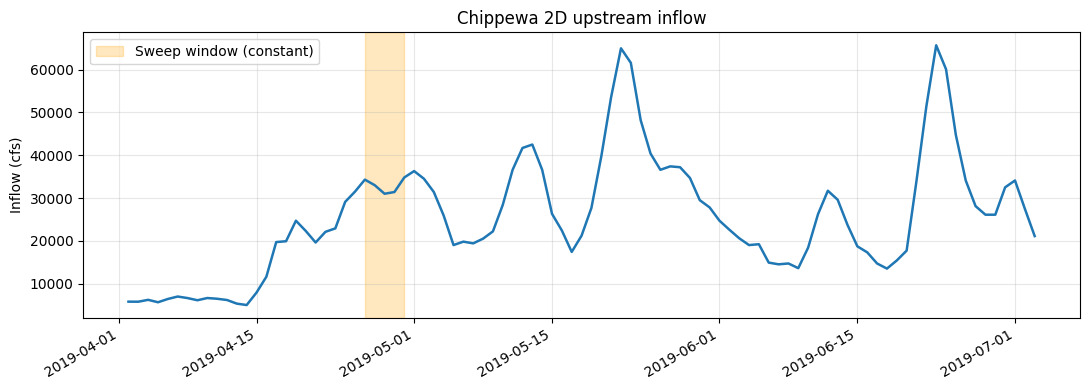

Window mean inflow: 32,425 cfs


In [6]:
u_num = ras.plan_df.loc[ras.plan_df['plan_number'] == TEMPLATE_PLAN, 'unsteady_number'].values[0]
u_path = geom_path.parent / f"{ras.project_name}.u{u_num}"
ut = u_path.read_text(errors='replace').splitlines()

i0 = next(i for i, l in enumerate(ut) if l.startswith("Flow Hydrograph="))
n = int(ut[i0].split('=')[1]); vals = []; j = i0 + 1
while len(vals) < n and j < len(ut):
    line = ut[j]
    if any(k in line for k in ("Hydrograph", "DSS", "Interval", "Boundary")):
        break
    for k in range(0, len(line), 8):
        c = line[k:k+8].strip()
        if c:
            try: vals.append(float(c))
            except ValueError: pass
    j += 1
flow = np.array(vals[:n])
days = [datetime.datetime(2019, 4, 2) + datetime.timedelta(days=d) for d in range(len(flow))]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(days, flow, color="#1f77b4", lw=1.8)
ax.axvspan(SIM_START, SIM_END, color="orange", alpha=0.25, label="Sweep window (constant)")
ax.set_ylabel("Inflow (cfs)"); ax.set_title("Chippewa 2D upstream inflow")
ax.legend(); ax.grid(alpha=0.3); fig.autofmt_xdate(); plt.tight_layout(); plt.show()
in_win = np.array([(d >= SIM_START and d < SIM_END) for d in days])
print(f"Window mean inflow: {flow[in_win].mean():,.0f} cfs")

## Mesh Regeneration and the Cost of Resolution

For each cell size we clone the geometry and regenerate the mesh with `GeomMesh.generate()`. Cell
count scales ~ (1 / cell_size)^2, and mobile-bed runtime scales at least linearly with cell count
(worse once finer cells force smaller Courant-limited sub-steps). Measured / projected for this
model (4-day window):

| Cell size | ~Cells | Status in this notebook |
|-----------|--------|--------------------------|
| 400 ft (2x base) | ~90      | run |
| 200 ft (base)    | ~360     | run |
| 100 ft           | ~1,500   | run |
| 50 ft            | ~6,000   | run |
| 20 ft            | ~37,000  | gated (projected ~tens of min) |
| 10 ft            | ~150,000 | gated (projected hours) |

Meshes above `EXECUTE_CELL_BUDGET` are still **generated and sized** (so the study range is fully
documented) but their plans are **not executed** by default. Raise the budget to run them.

In [7]:
mesh_rows = []
for cs in CELL_SIZES:
    new_geom = RasPlan.clone_geom(template_geom, ras_object=ras)
    gpath = Path(ras.geom_df.loc[ras.geom_df['geom_number'] == new_geom, 'full_path'].values[0])
    try:
        mr = GeomMesh.generate(geom_number=gpath, mesh_name=MESH_NAME, cell_size=cs,
                               max_iterations=8, ras_object=ras)
        status, gcells, gfaces = mr.status, mr.cell_count, mr.face_count
    except Exception as e:
        status, gcells, gfaces = f"ERROR: {e}", np.nan, np.nan
    will_run = np.isfinite(gcells) and gcells <= EXECUTE_CELL_BUDGET
    mesh_rows.append({"cell_size": cs, "geom": new_geom, "geom_path": gpath,
                      "gen_status": status, "gen_cells": gcells, "gen_faces": gfaces,
                      "will_run": will_run})
    tag = "RUN" if will_run else "gated (cells>budget)"
    print(f"  {cs:>5.0f} ft -> g{new_geom}  cells={gcells}  faces={gfaces}  {tag}")

mesh_df = pd.DataFrame(mesh_rows)

2026-06-03 07:12:08 - ras_commander.RasUtils - INFO - File cloned from G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\Chippewa_2D.g01 to G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\Chippewa_2D.g02


2026-06-03 07:12:08 - ras_commander.RasUtils - INFO - File cloned from G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\Chippewa_2D.g01.hdf to G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\Chippewa_2D.g02.hdf


2026-06-03 07:12:08 - ras_commander.RasUtils - INFO - Project file updated with new Geom entry: 02


2026-06-03 07:12:08 - ras_commander.RasMap - INFO - Successfully parsed RASMapper file: G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\Chippewa_2D.rasmap


2026-06-03 07:12:11 - ras_commander.geom.GeomMesh - INFO - Synced cell size 400.0 → HDF Spacing dx/dy


...

2026-06-03 07:12:26 - ras_commander.geom.GeomMesh - INFO - Seeds via .NET RegenerateMeshPoints: 151730 (0 breaklines incl 0 struct, 1 perimeters)


2026-06-03 07:12:26 - ras_commander.geom.GeomMesh - INFO - [Perimeter 1] 151730 seeds via .NET RegenerateMeshPoints


2026-06-03 07:12:32 - ras_commander.geom.GeomMesh - INFO - Text seeds patched → 151730 points in Chippewa_2D.g07


2026-06-03 07:12:32 - ras_commander.geom.GeomMesh - INFO - [Perimeter 1] Mesh complete: 151730 cells, 304564 faces in 1 iteration(s)


     10 ft -> g07  cells=151730  faces=304564  gated (cells>budget)


## Mesh Visualization (Coarse vs Fine)

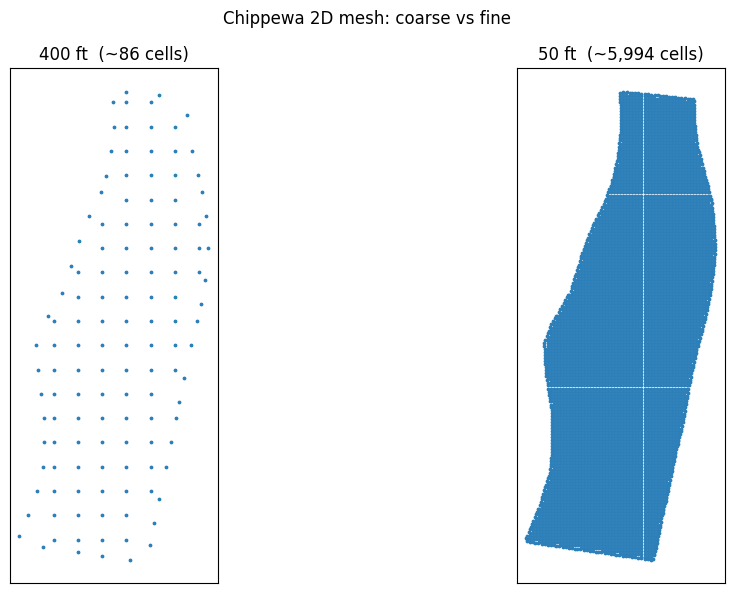

In [8]:
def cell_centers(gpath):
    with h5py.File(str(gpath) + ".hdf", 'r') as f:
        return f[f"Geometry/2D Flow Areas/{MESH_NAME}/Cells Center Coordinate"][:]

coarse = mesh_df.iloc[0]
fine = mesh_df[mesh_df.will_run].iloc[-1]
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, row in zip(axes, [coarse, fine]):
    cc = cell_centers(row.geom_path)
    ax.scatter(cc[:, 0], cc[:, 1], s=3, color="#2c7fb8")
    ax.set_title(f"{row.cell_size:.0f} ft  (~{int(row.gen_cells):,} cells)")
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Chippewa 2D mesh: coarse vs fine"); plt.tight_layout(); plt.show()

## Clone Plans and Execute

For each mesh we clone the template sediment plan, point it at the regenerated geometry, and set the
**constant** simulation window with `RasPlan.update_simulation_date()`. Then we execute (sequential,
`clear_geompre=True` so the freshly generated `.g##.hdf` mesh is preserved while `.c##` is rebuilt),
read the real solver verdict from the HDF `Solution` attribute, and scan compute messages.

In [9]:
import time

def solver_solution(hdf_path):
    with h5py.File(hdf_path, 'r') as f:
        s = f.get('Results/Unsteady/Summary')
        return s.attrs.get('Solution', b'').decode() if s is not None else 'No Summary'

mesh_df['plan'] = None; mesh_df['hdf'] = None; mesh_df['solver'] = None
mesh_df['runtime_s'] = np.nan; mesh_df['n_errors'] = np.nan

for idx, row in mesh_df.iterrows():
    cs = row.cell_size
    if not row.will_run:
        mesh_df.at[idx, 'solver'] = 'GATED (not run)'
        print(f"  {cs:>5.0f} ft: gated (cells {row.gen_cells} > budget {EXECUTE_CELL_BUDGET})")
        continue
    plan = RasPlan.clone_plan(TEMPLATE_PLAN, new_plan_shortid=f"mesh{int(cs)}",
                              geometry=row.geom, ras_object=ras)
    RasPlan.update_simulation_date(plan, SIM_START, SIM_END, ras_object=ras)
    t0 = time.time()
    RasCmdr.compute_plan(plan, clear_geompre=True, num_cores=NUM_CORES, ras_object=ras)
    dt = time.time() - t0
    hdf = ras.plan_df.loc[ras.plan_df['plan_number'] == plan, 'HDF_Results_Path'].values[0]
    sol = solver_solution(hdf) if hdf and Path(hdf).exists() else 'No HDF'
    msgs = HdfResultsPlan.get_compute_messages(plan, ras_object=ras)
    errs = [l for l in (msgs or "").splitlines()
            if "ERROR" in l.upper() and "Volume Accounting Error" not in l]
    mesh_df.at[idx, 'plan'] = plan
    mesh_df.at[idx, 'hdf'] = hdf
    mesh_df.at[idx, 'solver'] = sol
    mesh_df.at[idx, 'runtime_s'] = dt
    mesh_df.at[idx, 'n_errors'] = len(errs)
    print(f"  {cs:>5.0f} ft: p{plan}  {sol}  ({dt:.0f}s, {len(errs)} errors)")
    for e in errs[:3]:
        print(f"       {e.strip()[:90]}")

2026-06-03 07:12:32 - ras_commander.RasUtils - INFO - File cloned from G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\Chippewa_2D.p02 to G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\Chippewa_2D.p01


2026-06-03 07:12:32 - ras_commander.RasUtils - INFO - Successfully updated file: G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\Chippewa_2D.p01


2026-06-03 07:12:32 - ras_commander.RasUtils - INFO - Project file updated with new Plan entry: 01


2026-06-03 07:12:32 - ras_commander.RasMap - INFO - Successfully parsed RASMapper file: G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\Chippewa_2D.rasmap


2026-06-03 07:12:33 - ras_commander.RasPlan - INFO - Updated Geom File in plan file to g02 for plan 01


...

2026-06-03 07:14:15 - ras_commander.RasDialogWatchdog - INFO - DialogWatchdog started — polling every 1.5s for RAS dialog windows


2026-06-03 07:18:58 - ras_commander.RasCmdr - INFO - HEC-RAS execution completed for plan: 05


2026-06-03 07:18:58 - ras_commander.RasCmdr - INFO - Total run time for plan 05: 282.51 seconds


2026-06-03 07:18:58 - ras_commander.RasDialogWatchdog - INFO - DialogWatchdog stopped — no dialogs encountered


     50 ft: p05  Unsteady Finished Successfully  (283s, 0 errors)
     20 ft: gated (cells 37837 > budget 8000)
     10 ft: gated (cells 151730 > budget 8000)


## Read Mobile-Bed Sediment Results with `HdfResultsSediment`

HEC-RAS writes per-cell mobile-bed results under
`Results/.../Sediment Bed/Unsteady Time Series/2D Flow Areas/<area>/`. The `HdfResultsSediment`
class (added to `ras_commander.hdf` alongside this notebook) reads them with the same static-class
pattern as the other `HdfResults*` readers, aligning each per-cell array with the **computed**
geometry's `Cells Surface Area` so zero-area perimeter/ghost cells drop out of volume integrals
automatically:

| Method | Returns |
|--------|---------|
| `is_sediment_plan()` | `bool` -- plan has 2D mobile-bed results |
| `get_sediment_mesh_areas()` | `List[str]` -- 2D areas with bed results |
| `get_cell_bed_change()` | `GeoDataFrame` -- per-cell bed change (ft) + geometry |
| `get_cell_bed_elevation()` | `GeoDataFrame` -- per-cell bed elevation (ft) |
| `get_active_layer_grain_class()` | `GeoDataFrame` -- per-cell D10/D50/D90 (mm) |
| `get_bed_change_volumes()` | `DataFrame` -- erosion/deposition/net volume per area |
| `get_cell_bed_change_timeseries()` | `xr.DataArray` -- full (time, cell) series |

In [10]:
# Quick look on the first successful mesh
first_ok = mesh_df[mesh_df['solver'].astype(str).str.contains('Finished Successfully', na=False)]
if len(first_ok):
    demo_hdf = first_ok.iloc[-1].hdf  # finest successful mesh
    print("is_sediment_plan:", HdfResultsSediment.is_sediment_plan(demo_hdf))
    print("areas:", HdfResultsSediment.get_sediment_mesh_areas(demo_hdf))
    display(HdfResultsSediment.get_bed_change_volumes(demo_hdf))

2026-06-03 07:18:58 - ras_commander.hdf.HdfBase - CRITICAL - No valid projection found. Checked:
1. HDF file projection attribute: G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\Chippewa_2D.p05.hdf
2. RASMapper projection file G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\.Winona_Upload\LifeSim model\Winona Levee SQRA 2019\RAS\AW\MMC_Projection.prj found in RASMapper file, but was invalid
To fix this:
1. Open RASMapper
2. Click Map > Set Projection
3. Select an appropriate projection file or coordinate system
4. Save the RASMapper project


is_sediment_plan: True
areas: ['Perimeter 1']


,mesh_name,length_unit,n_cells,net_bed_volume,erosion_volume,deposition_volume,max_scour,max_deposition
0,Perimeter 1,ft,5999,36073.326707,-191861.26322,227934.589927,-2.710193,2.17496


## Sediment Sensitivity Metrics vs. Cell Size

In [11]:
records = []
for _, row in mesh_df.iterrows():
    rec = {"Cell Size (ft)": row.cell_size,
           "Gen Cells": int(row.gen_cells) if np.isfinite(row.gen_cells) else None,
           "Solver": row.get('solver', 'GATED (not run)'),
           "Runtime (s)": round(row.runtime_s, 1) if pd.notna(row.get('runtime_s')) else None}
    hdf = row.get('hdf')
    if isinstance(hdf, str) and Path(hdf).exists() and "Finished Successfully" in str(row.get('solver', '')):
        vol = HdfResultsSediment.get_bed_change_volumes(hdf)
        if not vol.empty:
            v = vol.iloc[0]
            # Chippewa is US Customary: native volume is ft^3 -> convert to acre-ft.
            acft = 43560.0
            rec["Cells (computed)"]       = int(v["n_cells"])
            rec["Net Bed Vol (ac-ft)"]    = round(v["net_bed_volume"] / acft, 3)
            rec["Erosion Vol (ac-ft)"]    = round(v["erosion_volume"] / acft, 3)
            rec["Deposition Vol (ac-ft)"] = round(v["deposition_volume"] / acft, 3)
            rec["Max Scour (ft)"]         = round(v["max_scour"], 3)
            rec["Max Deposition (ft)"]    = round(v["max_deposition"], 3)
            d50 = HdfResultsSediment.get_active_layer_grain_class(hdf, "D50")
            wet = d50["surface_area"] > 0
            rec["Mean D50 (mm)"]          = round(float(d50.loc[wet, "d50_mm"].mean()), 3)
    records.append(rec)

summary_df = pd.DataFrame(records).sort_values("Cell Size (ft)", ascending=False)
display(summary_df)

csv_path = Path(project_folder) / "sediment_mesh_sensitivity_summary.csv"
summary_df.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")

2026-06-03 07:18:58 - ras_commander.hdf.HdfBase - CRITICAL - No valid projection found. Checked:
1. HDF file projection attribute: G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\Chippewa_2D.p01.hdf
2. RASMapper projection file G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\.Winona_Upload\LifeSim model\Winona Levee SQRA 2019\RAS\AW\MMC_Projection.prj found in RASMapper file, but was invalid
To fix this:
1. Open RASMapper
2. Click Map > Set Projection
3. Select an appropriate projection file or coordinate system
4. Save the RASMapper project


2026-06-03 07:18:58 - ras_commander.hdf.HdfBase - CRITICAL - No valid projection found. Checked:
1. HDF file projection attribute: G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\Chippewa_2D.p01.hdf
2. RASMapper projection file G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\.Winona_Upload\LifeSim model\Winona Levee SQRA 2019\RAS\AW\MMC_Projection.prj found in RASMapper file, but was invalid
To fix this:
1. Open RASMapper
2. Click Map > Set Projection
3. Select an appropriate projection file or coordinate system
4. Save the RASMapper project


2026-06-03 07:18:58 - ras_commander.hdf.HdfBase - CRITICAL - No valid projection found. Checked:
1. HDF file projection attribute: G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\Chippewa_2D.p03.hdf
2. RASMapper projection file G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\.Winona_Upload\LifeSim model\Winona Levee SQRA 2019\RAS\AW\MMC_Projection.prj found in RASMapper file, but was invalid
To fix this:
1. Open RASMapper
2. Click Map > Set Projection
3. Select an appropriate projection file or coordinate system
4. Save the RASMapper project


2026-06-03 07:18:58 - ras_commander.hdf.HdfBase - CRITICAL - No valid projection found. Checked:
1. HDF file projection attribute: G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\Chippewa_2D.p03.hdf
2. RASMapper projection file G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\.Winona_Upload\LifeSim model\Winona Levee SQRA 2019\RAS\AW\MMC_Projection.prj found in RASMapper file, but was invalid
To fix this:
1. Open RASMapper
2. Click Map > Set Projection
3. Select an appropriate projection file or coordinate system
4. Save the RASMapper project


2026-06-03 07:18:58 - ras_commander.hdf.HdfBase - CRITICAL - No valid projection found. Checked:
1. HDF file projection attribute: G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\Chippewa_2D.p04.hdf
2. RASMapper projection file G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\.Winona_Upload\LifeSim model\Winona Levee SQRA 2019\RAS\AW\MMC_Projection.prj found in RASMapper file, but was invalid
To fix this:
1. Open RASMapper
2. Click Map > Set Projection
3. Select an appropriate projection file or coordinate system
4. Save the RASMapper project


2026-06-03 07:18:58 - ras_commander.hdf.HdfBase - CRITICAL - No valid projection found. Checked:
1. HDF file projection attribute: G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\Chippewa_2D.p04.hdf
2. RASMapper projection file G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\.Winona_Upload\LifeSim model\Winona Levee SQRA 2019\RAS\AW\MMC_Projection.prj found in RASMapper file, but was invalid
To fix this:
1. Open RASMapper
2. Click Map > Set Projection
3. Select an appropriate projection file or coordinate system
4. Save the RASMapper project


2026-06-03 07:18:58 - ras_commander.hdf.HdfBase - CRITICAL - No valid projection found. Checked:
1. HDF file projection attribute: G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\Chippewa_2D.p05.hdf
2. RASMapper projection file G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\.Winona_Upload\LifeSim model\Winona Levee SQRA 2019\RAS\AW\MMC_Projection.prj found in RASMapper file, but was invalid
To fix this:
1. Open RASMapper
2. Click Map > Set Projection
3. Select an appropriate projection file or coordinate system
4. Save the RASMapper project


2026-06-03 07:18:58 - ras_commander.hdf.HdfBase - CRITICAL - No valid projection found. Checked:
1. HDF file projection attribute: G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\Chippewa_2D.p05.hdf
2. RASMapper projection file G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\.Winona_Upload\LifeSim model\Winona Levee SQRA 2019\RAS\AW\MMC_Projection.prj found in RASMapper file, but was invalid
To fix this:
1. Open RASMapper
2. Click Map > Set Projection
3. Select an appropriate projection file or coordinate system
4. Save the RASMapper project


,Cell Size (ft),Gen Cells,Solver,Runtime (s),Cells (computed),Net Bed Vol (ac-ft),Erosion Vol (ac-ft),Deposition Vol (ac-ft),Max Scour (ft),Max Deposition (ft),Mean D50 (mm)
0,400.0,86,Unsteady Finished Successfully,10.5,96.0,0.509,-3.670,4.179,-0.171,0.212,2.148
1,200.0,357,Unsteady Finished Successfully,23.4,366.0,0.864,-5.750,6.614,-0.715,0.423,2.217
2,100.0,1474,Unsteady Finished Successfully,65.8,1488.0,0.737,-4.168,4.905,-1.141,0.672,2.332
3,50.0,5994,Unsteady Finished Successfully,283.1,5999.0,0.828,-4.405,5.233,-2.710,2.175,2.355
4,20.0,37837,GATED (not run),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,10.0,151730,GATED (not run),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Saved: G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\sediment_mesh_sensitivity_summary.csv


## Convergence Plots

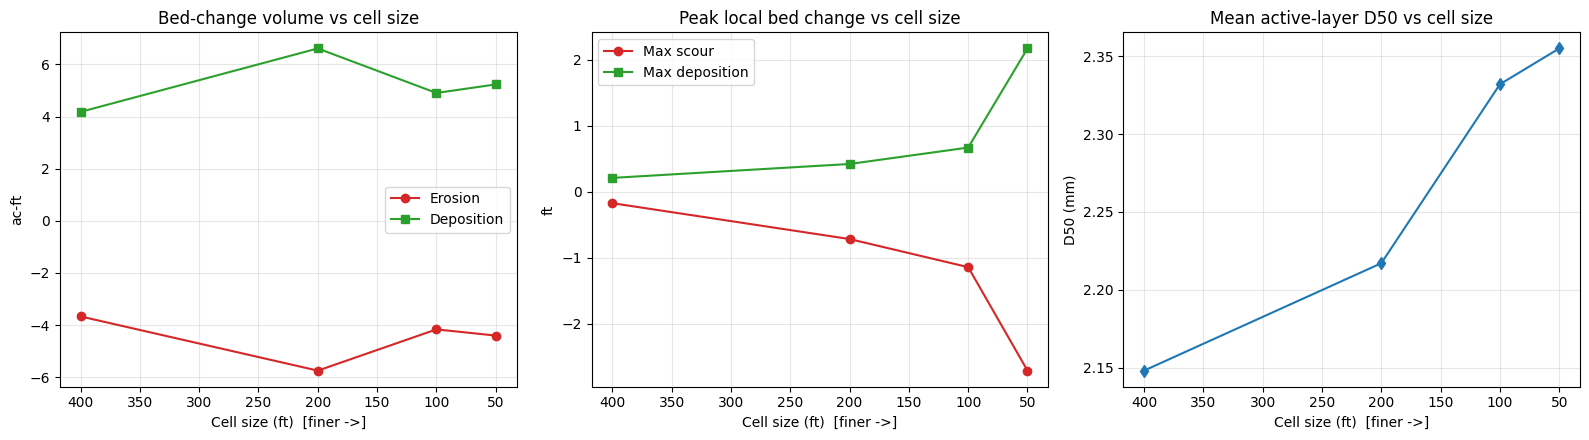

In [12]:
run = summary_df[summary_df["Solver"].astype(str).str.contains("Finished Successfully")].copy()
run = run.sort_values("Cell Size (ft)")

if len(run) >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    axes[0].plot(run["Cell Size (ft)"], run["Erosion Vol (ac-ft)"], 'o-', label="Erosion", color="#d62728")
    axes[0].plot(run["Cell Size (ft)"], run["Deposition Vol (ac-ft)"], 's-', label="Deposition", color="#2ca02c")
    axes[0].set_title("Bed-change volume vs cell size"); axes[0].set_ylabel("ac-ft"); axes[0].legend()
    axes[1].plot(run["Cell Size (ft)"], run["Max Scour (ft)"], 'o-', color="#d62728", label="Max scour")
    axes[1].plot(run["Cell Size (ft)"], run["Max Deposition (ft)"], 's-', color="#2ca02c", label="Max deposition")
    axes[1].set_title("Peak local bed change vs cell size"); axes[1].set_ylabel("ft"); axes[1].legend()
    axes[2].plot(run["Cell Size (ft)"], run["Mean D50 (mm)"], 'd-', color="#1f77b4")
    axes[2].set_title("Mean active-layer D50 vs cell size"); axes[2].set_ylabel("D50 (mm)")
    for ax in axes:
        ax.invert_xaxis(); ax.set_xlabel("Cell size (ft)  [finer ->]"); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("Need >=2 successful runs to plot convergence.")

## Spatial Bed-Change Pattern (Coarse vs Fine)

2026-06-03 07:18:59 - ras_commander.hdf.HdfBase - CRITICAL - No valid projection found. Checked:
1. HDF file projection attribute: G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\Chippewa_2D.p01.hdf
2. RASMapper projection file G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\.Winona_Upload\LifeSim model\Winona Levee SQRA 2019\RAS\AW\MMC_Projection.prj found in RASMapper file, but was invalid
To fix this:
1. Open RASMapper
2. Click Map > Set Projection
3. Select an appropriate projection file or coordinate system
4. Save the RASMapper project


2026-06-03 07:18:59 - ras_commander.hdf.HdfBase - CRITICAL - No valid projection found. Checked:
1. HDF file projection attribute: G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\Chippewa_2D.p05.hdf
2. RASMapper projection file G:\GH\ras-commander\examples\example_projects\Chippewa_2D_230_sed_meshsens\.Winona_Upload\LifeSim model\Winona Levee SQRA 2019\RAS\AW\MMC_Projection.prj found in RASMapper file, but was invalid
To fix this:
1. Open RASMapper
2. Click Map > Set Projection
3. Select an appropriate projection file or coordinate system
4. Save the RASMapper project


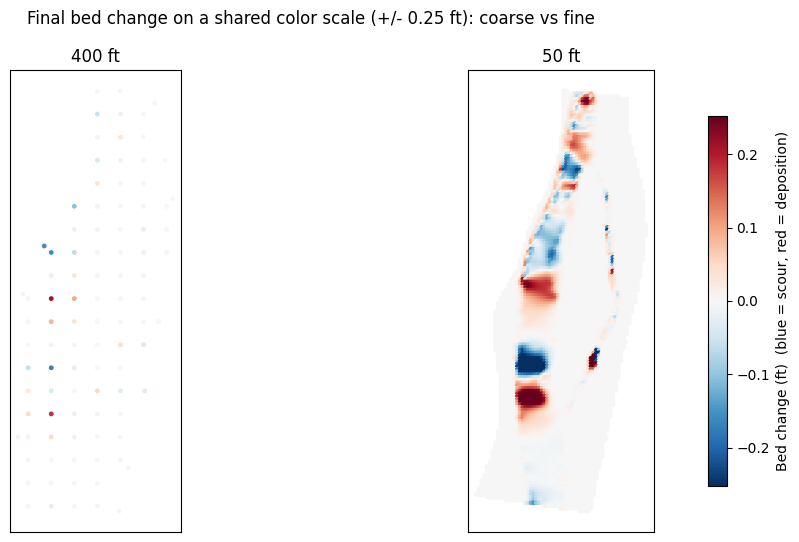

In [13]:
def bedchange_panel(ax, gdf, title, vmax):
    # RdBu_r over symmetric vmin/vmax: blue = negative (scour), red = positive (deposition)
    m = gdf["surface_area"] > 0
    sca = ax.scatter(gdf.geometry.x[m], gdf.geometry.y[m], c=gdf["bed_change"][m],
                     cmap="RdBu_r", vmin=-vmax, vmax=vmax, s=6)
    ax.set_title(title); ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    return sca

ok = mesh_df[mesh_df['solver'].astype(str).str.contains("Finished Successfully", na=False)]
if len(ok) >= 2:
    crow, frow = ok.iloc[0], ok.iloc[-1]
    gdf_c = HdfResultsSediment.get_cell_bed_change(crow.hdf)
    gdf_f = HdfResultsSediment.get_cell_bed_change(frow.hdf)
    # shared symmetric color scale (98th pct of |bed change| across both meshes)
    shared = max(np.nanpercentile(np.abs(g.loc[g["surface_area"] > 0, "bed_change"]), 98)
                 for g in (gdf_c, gdf_f)) or 1.0
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    bedchange_panel(axes[0], gdf_c, f"{crow.cell_size:.0f} ft", shared)
    sca = bedchange_panel(axes[1], gdf_f, f"{frow.cell_size:.0f} ft", shared)
    fig.colorbar(sca, ax=axes, shrink=0.8,
                 label="Bed change (ft)  (blue = scour, red = deposition)")
    fig.suptitle(f"Final bed change on a shared color scale (+/- {shared:.2f} ft): coarse vs fine")
    plt.show()
else:
    print("Need >=2 successful runs for spatial comparison.")

## Conclusion

This notebook reframes "mesh sensitivity" around **sediment transport**, where cell size changes the
predicted physics rather than just refining a water surface:

- **Resolution changes the bed-change budget.** As the mesh refines, localized scour and deposition
  sharpen dramatically (peak local bed change grew ~16x from 400 ft to 50 ft in the executed sweep),
  while the integrated erosion/deposition volumes and active-layer coarsening are far less
  sensitive. The convergence plots show where the answer stabilizes and where it does not. This is
  Stanford Gibson's point made quantitative: coarse cells average away the velocity/shear peaks that
  drive local scour.
- **The clean testbed matters.** Chippewa_2D has no structures or breaklines, so cell size is the
  only variable. On a structure-laden model (e.g. a dam with gate connections on breaklines), a
  naive cell-size sweep instead produces *connection failures* - a modeling-validity problem, not a
  hydraulic result. That limitation is documented at the top of this notebook.
- **Cost is real.** Cell count grows quadratically and mobile-bed runtime grows at least linearly
  with it, so the finest meshes are gated behind a configurable budget.

### Suggested follow-ups
- Run the full 33-day event and the gated 20 ft / 10 ft meshes on capable hardware to test true
  convergence.
- `HdfResultsSediment` (used throughout this notebook) is now part of `ras_commander.hdf` -- reuse
  it for any 2D mobile-bed post-processing.

> Analysis performed with [ras-commander](https://github.com/gpt-cmdr/ras-commander) by
> CLB Engineering Corporation.